In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# 1. Load the dataset
df = pd.read_csv('diabetes_bagging.csv')

# Split data into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [3]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a standard Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

In [4]:
# 3. Apply BaggingClassifier (Ensemble of Decision Trees)
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)

In [5]:
# 4. Compare Accuracy
print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Bagging Classifier Accuracy: {acc_bag:.4f}")

Decision Tree Accuracy: 1.0000
Bagging Classifier Accuracy: 1.0000


C:\Users\HP\AppData\Local\Temp\ipykernel_28320\2252209783.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, ax=axes[0], palette='magma')


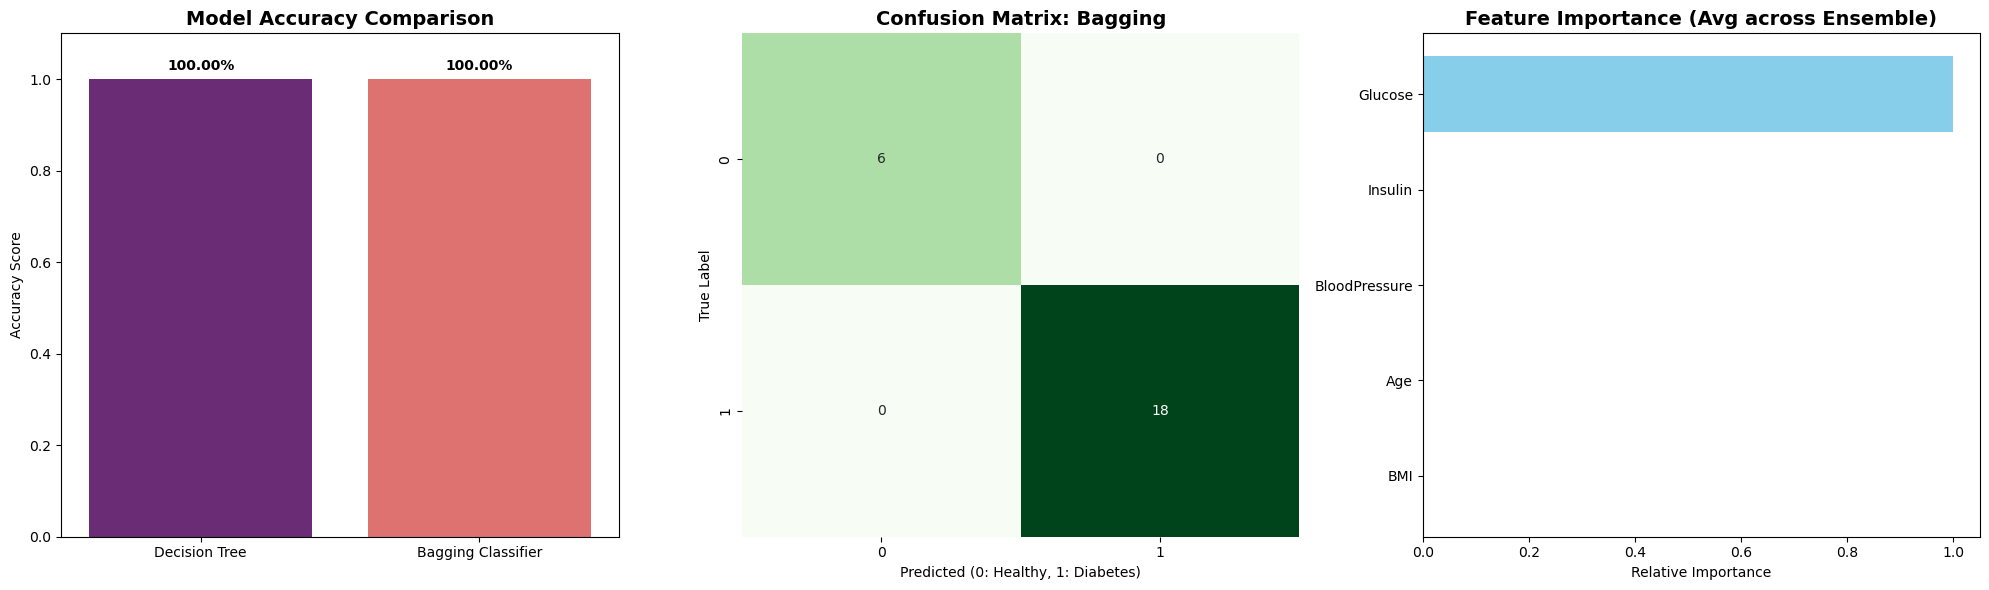

In [7]:
import numpy as np

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Subplot 1: Accuracy Comparison (Bar Chart) ---
models = ['Decision Tree', 'Bagging Classifier']
accuracies = [acc_dt, acc_bag]
sns.barplot(x=models, y=accuracies, ax=axes[0], palette='magma')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

# --- Subplot 2: Confusion Matrix (Heatmap) ---
cm_bag = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm_bag, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('Confusion Matrix: Bagging', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted (0: Healthy, 1: Diabetes)')
axes[1].set_ylabel('True Label')

# --- Subplot 3: Feature Importance (The "Why") ---
# Bagging doesn't have a direct feature_importances_ attribute like Random Forest,
# so we average the importance of all underlying trees.
importances = np.mean([tree.feature_importances_ for tree in bag_clf.estimators_], axis=0)
indices = np.argsort(importances)

axes[2].barh(range(len(indices)), importances[indices], color='skyblue', align='center')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([X.columns[i] for i in indices])
axes[2].set_title('Feature Importance (Avg across Ensemble)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()